**Task A: Database Inspection and Cleaning**

In [36]:
import sqlite3
import pandas as pd
from pathlib import Path
import numpy as np

In [2]:
db_path = Path("ecommerce_hackathon.db")

print("Notebook working folder:", Path.cwd())
print("Database exists:", db_path.exists())

Notebook working folder: C:\Users\anas\Desktop\Final_Data_Science_Hackathon
Database exists: True


In [3]:
# Read-only connection: original database modify nahi hogi
connection = sqlite3.connect(
    db_path.resolve().as_uri() + "?mode=ro",
    uri=True
)

pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type = 'table'",
    connection
)

,name
0,customers
1,products
2,orders
3,reviews


In [5]:
customers = pd.read_sql_query("SELECT * FROM customers", connection)
products = pd.read_sql_query("SELECT * FROM products", connection)
orders = pd.read_sql_query("SELECT * FROM orders", connection)
reviews = pd.read_sql_query("SELECT * FROM reviews", connection)

tables = {
    "customers": customers,
    "products": products,
    "orders": orders,
    "reviews": reviews
}

In [6]:
for name, df in tables.items():
    print(f"\nTABLE: {name}")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    display(df.head())


TABLE: customers
Shape: (8000, 9)
Columns: ['customer_id', 'customer_name', 'age', 'gender', 'city', 'signup_date', 'membership_type', 'email', 'phone']


,customer_id,customer_name,age,gender,city,signup_date,membership_type,email,phone
0,1,Hassan Khan,20.0,Male,Karachi,2026-02-27,Standard,hassan.khan1@example.com,+92-3241-4744854
1,2,Maham Raza,33.0,Female,Rawalpindi,2025-10-17,Silver,maham.raza2@example.com,+92-3421-8078673
2,3,Ahmed Khan,25.0,Male,Karachi,2022-07-11,Standard,ahmed.khan3@example.com,+92-3139-9478454
3,4,Salman Khan,26.0,Male,Lahore,2025-02-23,Standard,salman.khan4@example.com,+92-3193-8038374
4,5,Noor Awan,27.0,Female,Lahore,2025-04-21,Standard,noor.awan5@example.com,+92-3210-3678638



TABLE: products
Shape: (1000, 6)
Columns: ['product_id', 'product_name', 'category', 'brand', 'unit_price', 'stock_quantity']


,product_id,product_name,category,brand,unit_price,stock_quantity
0,1,Readings Exam Guide Premium,Books & Stationery,Readings,566.45,103
1,2,Samsung Webcam Classic,Electronics,Samsung,10567.23,138
2,3,CA Sports Water Bottle Classic,Sports & Fitness,CA Sports,6665.04,63
3,4,LU Spice Mix Classic,Groceries,LU,516.49,113
4,5,L'Oreal Shampoo 2026,Beauty,L'Oreal,2581.35,107



TABLE: orders
Shape: (65000, 10)
Columns: ['order_id', 'customer_id', 'product_id', 'order_date', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'returned']


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,payment_method,delivery_days,returned
0,1,2367,389,2026-04-30,1,398.27,0.108,Cash on Delivery,1.0,0
1,2,2038,927,2026-02-09,2,44488.20,0.084,Debit/Credit Card,1.0,0
2,3,6285,909,2026-03-30,1,4719.91,0.125,Cash on Delivery,1.0,0
3,4,3714,117,2026-03-24,1,2053.64,0.118,Easypaisa,4.0,0
4,5,3021,733,2024-12-13,1,31378.77,0.087,Debit/Credit Card,2.0,0



TABLE: reviews
Shape: (26000, 6)
Columns: ['review_id', 'customer_id', 'product_id', 'review_date', 'rating', 'review_text']


,review_id,customer_id,product_id,review_date,rating,review_text
0,1,7210,787,2026-07-28,4,"I would buy this again, item feels durable. Re..."
1,2,5566,765,2026-05-16,5,"Very satisfied, seller description was accurat..."
2,3,6106,743,2025-10-21,4,"Very satisfied, quality feels premium. Good va..."
3,4,2735,90,2026-03-25,4,"Product arrived in great condition, quality fe..."
4,5,2124,197,2026-02-23,4,"Good experience overall, packing was neat. Wil..."


In [7]:
for name, df in tables.items():
    print(f"\nTABLE: {name}")

    display(
        df.isna()
          .sum()
          .rename("missing_count")
          .to_frame()
    )

    print("Duplicate rows:", df.duplicated().sum())

    id_column = df.columns[0]
    print("Duplicate IDs:", df[id_column].duplicated().sum())


TABLE: customers


,missing_count
customer_id,0
customer_name,0
age,100
gender,0
city,0
signup_date,0
membership_type,0
email,0
phone,0


Duplicate rows: 0
Duplicate IDs: 0

TABLE: products


,missing_count
product_id,0
product_name,0
category,0
brand,20
unit_price,0
stock_quantity,0


Duplicate rows: 0
Duplicate IDs: 0

TABLE: orders


,missing_count
order_id,0
customer_id,0
product_id,0
order_date,0
quantity,0
unit_price,0
discount,0
payment_method,55
delivery_days,40
returned,0


Duplicate rows: 0
Duplicate IDs: 0

TABLE: reviews


,missing_count
review_id,0
customer_id,0
product_id,0
review_date,0
rating,0
review_text,48


Duplicate rows: 0
Duplicate IDs: 0


In [8]:
print("CUSTOMERS")
customers.info()

print("\nPRODUCTS")
products.info()

print("\nORDERS")
orders.info()

print("\nREVIEWS")
reviews.info()

CUSTOMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      8000 non-null   int64  
 1   customer_name    8000 non-null   object 
 2   age              7900 non-null   float64
 3   gender           8000 non-null   object 
 4   city             8000 non-null   object 
 5   signup_date      8000 non-null   object 
 6   membership_type  8000 non-null   object 
 7   email            8000 non-null   object 
 8   phone            8000 non-null   object 
dtypes: float64(1), int64(1), object(7)
memory usage: 562.6+ KB

PRODUCTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      1000 non-null   int64  
 1   product_name    1000 non-null   object 
 2   category      

In [9]:
customers.describe(include="all")
products.describe(include="all")
orders.describe(include="all")
reviews.describe(include="all")

,review_id,customer_id,product_id,review_date,rating,review_text
count,26000.000000,26000.000000,26000.000000,26000,26000.000000,25952
unique,NaN,NaN,NaN,1403,NaN,4486
top,NaN,NaN,NaN,2026-08-02,NaN,
freq,NaN,NaN,NaN,82,NaN,42
mean,13000.500000,3969.574769,494.774538,NaN,3.903423,NaN
std,7505.697836,2300.036782,285.921158,NaN,0.960517,NaN
min,1.000000,2.000000,1.000000,NaN,0.000000,NaN
25%,6500.750000,1935.000000,238.000000,NaN,3.000000,NaN
50%,13000.500000,4011.000000,498.000000,NaN,4.000000,NaN
75%,19500.250000,5996.250000,765.000000,NaN,5.000000,NaN


In [10]:
# Check missing values in all four tables

print("CUSTOMERS MISSING VALUES")
print(customers.isnull().sum())

print("\nPRODUCTS MISSING VALUES")
print(products.isnull().sum())

print("\nORDERS MISSING VALUES")
print(orders.isnull().sum())

print("\nREVIEWS MISSING VALUES")
print(reviews.isnull().sum())

CUSTOMERS MISSING VALUES
customer_id          0
customer_name        0
age                100
gender               0
city                 0
signup_date          0
membership_type      0
email                0
phone                0
dtype: int64

PRODUCTS MISSING VALUES
product_id         0
product_name       0
category           0
brand             20
unit_price         0
stock_quantity     0
dtype: int64

ORDERS MISSING VALUES
order_id           0
customer_id        0
product_id         0
order_date         0
quantity           0
unit_price         0
discount           0
payment_method    55
delivery_days     40
returned           0
dtype: int64

REVIEWS MISSING VALUES
review_id       0
customer_id     0
product_id      0
review_date     0
rating          0
review_text    48
dtype: int64


In [11]:
def missing_summary(df):
    missing = pd.DataFrame({
        "Missing Values": df.isnull().sum(),
        "Missing Percentage": (df.isnull().sum() / len(df)) * 100
    })

    return missing[missing["Missing Values"] > 0]


print("CUSTOMERS")
display(missing_summary(customers))

print("PRODUCTS")
display(missing_summary(products))

print("ORDERS")
display(missing_summary(orders))

print("REVIEWS")
display(missing_summary(reviews))

CUSTOMERS


,Missing Values,Missing Percentage
age,100,1.25


PRODUCTS


,Missing Values,Missing Percentage
brand,20,2.0


ORDERS


,Missing Values,Missing Percentage
payment_method,55,0.084615
delivery_days,40,0.061538


REVIEWS


,Missing Values,Missing Percentage
review_text,48,0.184615


In [12]:
print("Customers duplicates:", customers.duplicated().sum())

print("Products duplicates:", products.duplicated().sum())

print("Orders duplicates:", orders.duplicated().sum())

print("Reviews duplicates:", reviews.duplicated().sum())

Customers duplicates: 0
Products duplicates: 0
Orders duplicates: 0
Reviews duplicates: 0


In [13]:
print("Duplicate Customer IDs:",
      customers["customer_id"].duplicated().sum())

print("Duplicate Product IDs:",
      products["product_id"].duplicated().sum())

print("Duplicate Order IDs:",
      orders["order_id"].duplicated().sum())

print("Duplicate Review IDs:",
      reviews["review_id"].duplicated().sum())

Duplicate Customer IDs: 0
Duplicate Product IDs: 0
Duplicate Order IDs: 0
Duplicate Review IDs: 0


In [14]:
print("Invalid customer ages:")
display(customers[customers["age"] <= 0])

print("Invalid product prices:")
display(products[products["unit_price"] <= 0])

print("Invalid stock quantities:")
display(products[products["stock_quantity"] < 0])

print("Invalid order quantities:")
display(orders[orders["quantity"] <= 0])

print("Invalid order prices:")
display(orders[orders["unit_price"] <= 0])

print("Invalid discounts:")
display(orders[
    (orders["discount"] < 0) |
    (orders["discount"] > 1)
])

Invalid customer ages:


,customer_id,customer_name,age,gender,city,signup_date,membership_type,email,phone


Invalid product prices:


,product_id,product_name,category,brand,unit_price,stock_quantity


Invalid stock quantities:


...

,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,payment_method,delivery_days,returned
897,898,2582,20,2026-04-15,0,6227.64,0.142,Cash on Delivery,6.0,0
2208,2209,5979,250,2025-06-05,0,9273.43,0.054,Cash on Delivery,3.0,0
2954,2955,1145,574,2026-03-22,0,9233.19,0.047,Cash on Delivery,4.0,0
4134,4135,5918,733,2024-06-26,0,29576.90,0.082,Cash on Delivery,3.0,0
6330,6331,4079,749,2025-03-07,0,212.60,0.093,Bank Transfer,5.0,0
6803,6804,1615,574,2026-02-17,0,9059.17,0.111,Cash on Delivery,2.0,0
9416,9417,3919,231,2025-03-31,0,9603.63,0.101,Debit/Credit Card,4.0,0
11268,11269,1786,181,2024-01-26,0,824.55,0.203,Bank Transfer,4.0,0
12067,12068,2248,938,2025-11-08,0,8045.86,0.080,Cash on Delivery,2.0,1
18318,18319,1248,907,2026-06-19,0,1910.32,0.103,Cash on Delivery,4.0,0


Invalid order prices:


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,payment_method,delivery_days,returned
1342,1343,5642,765,2026-05-12,1,-126669.18,0.050,Cash on Delivery,5.0,0
2110,2111,2285,732,2024-03-03,1,-5001.21,0.046,Cash on Delivery,3.0,0
2438,2439,1606,766,2026-06-16,2,-1576.66,0.164,Bank Transfer,3.0,0
2726,2727,4295,806,2024-12-09,2,-4776.16,0.054,Cash on Delivery,5.0,0
2781,2782,5641,338,2026-04-05,1,-1503.95,0.057,Cash on Delivery,6.0,0
5615,5616,3000,982,2025-07-21,1,-1003.46,0.064,Cash on Delivery,3.0,0
9713,9714,6688,30,2026-04-14,2,-556.96,0.198,Debit/Credit Card,3.0,0
10217,10218,683,553,2026-05-27,1,-3292.94,0.115,Debit/Credit Card,2.0,0
10282,10283,2790,132,2025-07-28,1,-4067.62,0.147,Cash on Delivery,4.0,0
14125,14126,4640,174,2026-01-27,2,-8136.83,0.135,Debit/Credit Card,3.0,0


Invalid discounts:


,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,payment_method,delivery_days,returned


In [15]:
date_columns = {
    "customers": (customers, "signup_date"),
    "orders": (orders, "order_date"),
    "reviews": (reviews, "review_date")
}

for table_name, (df, column) in date_columns.items():

    converted_dates = pd.to_datetime(
        df[column],
        errors="coerce"
    )

    invalid_dates = converted_dates.isna().sum()

    print(table_name, "Invalid dates:", invalid_dates)

customers Invalid dates: 0
orders Invalid dates: 30
reviews Invalid dates: 16


In [16]:
print("Gender:")
print(customers["gender"].value_counts(dropna=False))

print("\nCity:")
print(customers["city"].value_counts(dropna=False))

print("\nMembership Type:")
print(customers["membership_type"].value_counts(dropna=False))

print("\nProduct Category:")
print(products["category"].value_counts(dropna=False))

print("\nPayment Method:")
print(orders["payment_method"].value_counts(dropna=False))

Gender:
gender
Male      4517
Female    3483
Name: count, dtype: int64

City:
city
Karachi         2149
Lahore          1461
Islamabad        798
Rawalpindi       658
Faisalabad       564
Multan           480
Peshawar         399
Hyderabad        318
Gujranwala       316
Quetta           237
Sialkot          234
Bahawalpur       159
Sargodha         157
KARACHI           10
karachi            7
 Lahore            6
lahore             5
LAHORE             4
rawalpindi         3
faisalabad         3
MULTAN             3
 Karachi           3
quetta             2
islamabad          2
GUJRANWALA         2
 Rawalpindi        2
 Hyderabad         1
peshawar           1
FAISALABAD         1
 Peshawar          1
 Multan            1
multan             1
 Faisalabad        1
 Bahawalpur        1
QUETTA             1
sargodha           1
RAWALPINDI         1
ISLAMABAD          1
 Gujranwala        1
bahawalpur         1
 Islamabad         1
hyderabad          1
PESHAWAR           1
 Sialkot      

In [17]:

print("Gender:")
print(customers["gender"].value_counts(dropna=False))

print("\nCity:")
print(customers["city"].value_counts(dropna=False))

print("\nMembership Type:")
print(customers["membership_type"].value_counts(dropna=False))

print("\nProduct Category:")
print(products["category"].value_counts(dropna=False))

print("\nPayment Method:")
print(orders["payment_method"].value_counts(dropna=False))

Gender:
gender
Male      4517
Female    3483
Name: count, dtype: int64

City:
city
Karachi         2149
Lahore          1461
Islamabad        798
Rawalpindi       658
Faisalabad       564
Multan           480
Peshawar         399
Hyderabad        318
Gujranwala       316
Quetta           237
Sialkot          234
Bahawalpur       159
Sargodha         157
KARACHI           10
karachi            7
 Lahore            6
lahore             5
LAHORE             4
rawalpindi         3
faisalabad         3
MULTAN             3
 Karachi           3
quetta             2
islamabad          2
GUJRANWALA         2
 Rawalpindi        2
 Hyderabad         1
peshawar           1
FAISALABAD         1
 Peshawar          1
 Multan            1
multan             1
 Faisalabad        1
 Bahawalpur        1
QUETTA             1
sargodha           1
RAWALPINDI         1
ISLAMABAD          1
 Gujranwala        1
bahawalpur         1
 Islamabad         1
hyderabad          1
PESHAWAR           1
 Sialkot      

In [18]:

# Check orders customer IDs

invalid_customers = orders[
    ~orders["customer_id"].isin(customers["customer_id"])
]

# Check orders product IDs

invalid_products = orders[
    ~orders["product_id"].isin(products["product_id"])
]

print("Invalid customer references:", len(invalid_customers))
print("Invalid product references:", len(invalid_products))

Invalid customer references: 0
Invalid product references: 0


In [19]:

# Check reviews customer IDs

invalid_review_customers = reviews[
    ~reviews["customer_id"].isin(customers["customer_id"])
]

# Check reviews product IDs

invalid_review_products = reviews[
    ~reviews["product_id"].isin(products["product_id"])
]

print("Invalid review customer references:",
      len(invalid_review_customers))

print("Invalid review product references:",
      len(invalid_review_products))

Invalid review customer references: 0
Invalid review product references: 0


In [20]:

customers_clean = customers.copy()
products_clean = products.copy()
orders_clean = orders.copy()
reviews_clean = reviews.copy()

print("Backup copies created successfully!")

Backup copies created successfully!


In [21]:

# Standardize customer categories

for col in ["gender", "city", "membership_type"]:
    customers_clean[col] = (
        customers_clean[col]
        .str.strip()
        .str.title()
    )

# Standardize product categories

for col in ["category", "brand"]:
    products_clean[col] = (
        products_clean[col]
        .str.strip()
        .str.title()
    )

# Standardize payment methods

orders_clean["payment_method"] = (
    orders_clean["payment_method"]
    .str.strip()
    .str.title()
)

print("Categorical values standardized!")

Categorical values standardized!


In [22]:

customers_clean["gender"] = customers_clean["gender"].fillna("Unknown")
customers_clean["city"] = customers_clean["city"].fillna("Unknown")
customers_clean["membership_type"] = customers_clean["membership_type"].fillna("Unknown")

products_clean["brand"] = products_clean["brand"].fillna("Unknown")

orders_clean["payment_method"] = orders_clean["payment_method"].fillna("Unknown")

print("Missing categorical values handled!")

Missing categorical values handled!


In [23]:
# Check invalid customer ages

invalid_age = customers_clean[
    customers_clean["age"] <= 0
]

print("Invalid ages:", len(invalid_age))


# Check invalid product prices

invalid_product_price = products_clean[
    products_clean["unit_price"] <= 0
]

print("Invalid product prices:", len(invalid_product_price))


# Check invalid stock quantities

invalid_stock = products_clean[
    products_clean["stock_quantity"] < 0
]

print("Invalid stock quantities:", len(invalid_stock))


# Check invalid order quantities

invalid_quantity = orders_clean[
    orders_clean["quantity"] <= 0
]

print("Invalid order quantities:", len(invalid_quantity))


# Check invalid order prices

invalid_order_price = orders_clean[
    orders_clean["unit_price"] <= 0
]

print("Invalid order prices:", len(invalid_order_price))

Invalid ages: 0
Invalid product prices: 0
Invalid stock quantities: 0
Invalid order quantities: 45
Invalid order prices: 35


In [24]:
print("Discount information:")

display(orders_clean["discount"].describe())

print("\nUnique discount values:")

print(orders_clean["discount"].value_counts().head(15))

Discount information:


count    65000.000000
mean         0.099039
std          0.043717
min          0.030000
25%          0.065000
50%          0.092000
75%          0.125000
max          0.375000
Name: discount, dtype: float64


Unique discount values:
discount
0.080    676
0.076    665
0.077    661
0.081    650
0.062    642
0.063    640
0.083    637
0.070    633
0.071    633
0.064    631
0.065    631
0.094    626
0.088    623
0.058    622
0.057    620
Name: count, dtype: int64


In [25]:
customers_clean["signup_date"] = pd.to_datetime(
    customers_clean["signup_date"],
    errors="coerce"
)

orders_clean["order_date"] = pd.to_datetime(
    orders_clean["order_date"],
    errors="coerce"
)

reviews_clean["review_date"] = pd.to_datetime(
    reviews_clean["review_date"],
    errors="coerce"
)

print("Date conversion completed!")

Date conversion completed!


In [26]:
customers_clean["signup_date"] = pd.to_datetime(
    customers_clean["signup_date"],
    errors="coerce"
)

orders_clean["order_date"] = pd.to_datetime(
    orders_clean["order_date"],
    errors="coerce"
)

reviews_clean["review_date"] = pd.to_datetime(
    reviews_clean["review_date"],
    errors="coerce"
)

print("Date conversion completed!")

Date conversion completed!


In [27]:
print("Customers:", customers_clean["signup_date"].isna().sum())

print("Orders:", orders_clean["order_date"].isna().sum())

print("Reviews:", reviews_clean["review_date"].isna().sum())

Customers: 0
Orders: 30
Reviews: 16


In [28]:
print("Discount information:")
display(orders_clean["discount"].describe())

print("\nUnique discount values:")
print(orders_clean["discount"].value_counts().head(15))

Discount information:


count    65000.000000
mean         0.099039
std          0.043717
min          0.030000
25%          0.065000
50%          0.092000
75%          0.125000
max          0.375000
Name: discount, dtype: float64


Unique discount values:
discount
0.080    676
0.076    665
0.077    661
0.081    650
0.062    642
0.063    640
0.083    637
0.070    633
0.071    633
0.064    631
0.065    631
0.094    626
0.088    623
0.058    622
0.057    620
Name: count, dtype: int64


In [29]:
print("Invalid customer ages:",
      (customers_clean["age"] <= 0).sum())

print("Invalid product prices:",
      (products_clean["unit_price"] <= 0).sum())

print("Invalid stock quantities:",
      (products_clean["stock_quantity"] < 0).sum())

print("Invalid order quantities:",
      (orders_clean["quantity"] <= 0).sum())

print("Invalid order prices:",
      (orders_clean["unit_price"] <= 0).sum())

Invalid customer ages: 0
Invalid product prices: 0
Invalid stock quantities: 0
Invalid order quantities: 45
Invalid order prices: 35


In [30]:
print("Discount Statistics:")

display(orders_clean["discount"].describe())

print("\nUnique Discount Values:")

print(orders_clean["discount"].value_counts().head(15))

Discount Statistics:


count    65000.000000
mean         0.099039
std          0.043717
min          0.030000
25%          0.065000
50%          0.092000
75%          0.125000
max          0.375000
Name: discount, dtype: float64


Unique Discount Values:
discount
0.080    676
0.076    665
0.077    661
0.081    650
0.062    642
0.063    640
0.083    637
0.070    633
0.071    633
0.064    631
0.065    631
0.094    626
0.088    623
0.058    622
0.057    620
Name: count, dtype: int64


In [31]:
print("Missing review text:",
      reviews_clean["review_text"].isnull().sum())

print("Invalid ratings:",
      ((reviews_clean["rating"] < 1) |
       (reviews_clean["rating"] > 5)).sum())

Missing review text: 48
Invalid ratings: 25


In [32]:

orders_clean["analysis_eligible"] = (
    orders_clean["quantity"].gt(0) &
    orders_clean["unit_price"].gt(0) &
    orders_clean["order_date"].notna() &
    orders_clean["discount"].between(0, 1)
)

print(orders_clean["analysis_eligible"].value_counts())

print("\nEligible orders:",
      orders_clean["analysis_eligible"].sum())

print("Ineligible orders:",
      (~orders_clean["analysis_eligible"]).sum())

analysis_eligible
True     64890
False      110
Name: count, dtype: int64

Eligible orders: 64890
Ineligible orders: 110


In [38]:

# Create sentiment labels

sentiment_data["sentiment"] = np.select(
    [
        sentiment_data["rating"].isin([1, 2]),
        sentiment_data["rating"] == 3,
        sentiment_data["rating"].isin([4, 5])
    ],
    [
        "Negative",
        "Neutral",
        "Positive"
    ],
    default="Unknown"
)

print("Original reviews:", len(reviews_clean))
print("Usable reviews:", len(sentiment_data))

print("\nSentiment distribution:")
print(sentiment_data["sentiment"].value_counts())

Original reviews: 26000
Usable reviews: 25927

Sentiment distribution:
sentiment
Positive    18453
Neutral      5462
Negative     2012
Name: count, dtype: int64


### Review Data Preparation

I prepared a separate dataset for sentiment analysis using the reviews table. I removed records with missing review text and excluded records with invalid ratings.

I converted customer ratings into three sentiment categories:

* Ratings 1–2: Negative
* Rating 3: Neutral
* Ratings 4–5: Positive

After preprocessing, 25,927 usable reviews remained from the original 26,000 records.

The sentiment distribution shows that positive reviews are the majority, followed by neutral and negative reviews. This class imbalance will be considered during model evaluation.


In [39]:
clean_tables = {
    "customers": customers_clean,
    "products": products_clean,
    "orders": orders_clean,
    "reviews": reviews_clean
}

for name, df in clean_tables.items():
    print(f"\n{name.upper()}")
    print("Shape:", df.shape)
    print("Missing values:")
    print(df.isnull().sum())


CUSTOMERS
Shape: (8000, 9)
Missing values:
customer_id          0
customer_name        0
age                100
gender               0
city                 0
signup_date          0
membership_type      0
email                0
phone                0
dtype: int64

PRODUCTS
Shape: (1000, 6)
Missing values:
product_id        0
product_name      0
category          0
brand             0
unit_price        0
stock_quantity    0
dtype: int64

ORDERS
Shape: (65000, 11)
Missing values:
order_id              0
customer_id           0
product_id            0
order_date           30
quantity              0
unit_price            0
discount              0
payment_method        0
delivery_days        40
returned              0
analysis_eligible     0
dtype: int64

REVIEWS
Shape: (26000, 6)
Missing values:
review_id       0
customer_id     0
product_id      0
review_date    16
rating          0
review_text    48
dtype: int64


In [40]:

clean_tables = {
    "customers": customers_clean,
    "products": products_clean,
    "orders": orders_clean,
    "reviews": reviews_clean
}

for name, df in clean_tables.items():

    print("\nTABLE:", name.upper())
    print("Shape:", df.shape)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:", df.duplicated().sum())


TABLE: CUSTOMERS
Shape: (8000, 9)

Missing Values:
customer_id          0
customer_name        0
age                100
gender               0
city                 0
signup_date          0
membership_type      0
email                0
phone                0
dtype: int64

Duplicate Rows: 0

TABLE: PRODUCTS
Shape: (1000, 6)

Missing Values:
product_id        0
product_name      0
category          0
brand             0
unit_price        0
stock_quantity    0
dtype: int64

Duplicate Rows: 0

TABLE: ORDERS
Shape: (65000, 11)

Missing Values:
order_id              0
customer_id           0
product_id            0
order_date           30
quantity              0
unit_price            0
discount              0
payment_method        0
delivery_days        40
returned              0
analysis_eligible     0
dtype: int64

Duplicate Rows: 0

TABLE: REVIEWS
Shape: (26000, 6)

Missing Values:
review_id       0
customer_id     0
product_id      0
review_date    16
rating          0
review_text    48


In [41]:

print("Discount minimum:",
      orders_clean["discount"].min())

print("Discount maximum:",
      orders_clean["discount"].max())

print("\nDiscount statistics:")

display(orders_clean["discount"].describe())

print("\nUnique discount values:")

print(orders_clean["discount"].value_counts().head(15))

Discount minimum: 0.03
Discount maximum: 0.375

Discount statistics:


count    65000.000000
mean         0.099039
std          0.043717
min          0.030000
25%          0.065000
50%          0.092000
75%          0.125000
max          0.375000
Name: discount, dtype: float64


Unique discount values:
discount
0.080    676
0.076    665
0.077    661
0.081    650
0.062    642
0.063    640
0.083    637
0.070    633
0.071    633
0.064    631
0.065    631
0.094    626
0.088    623
0.058    622
0.057    620
Name: count, dtype: int64


In [42]:
for name, df in clean_tables.items():
    print(name, ":", len(df), "rows")

customers : 8000 rows
products : 1000 rows
orders : 65000 rows
reviews : 26000 rows


In [43]:
print("Minimum discount:",
      orders_clean["discount"].min())

print("Maximum discount:",
      orders_clean["discount"].max())

print("Missing discounts:",
      orders_clean["discount"].isna().sum())

print("Discounts below 0:",
      (orders_clean["discount"] < 0).sum())

print("Discounts above 1:",
      (orders_clean["discount"] > 1).sum())

Minimum discount: 0.03
Maximum discount: 0.375
Missing discounts: 0
Discounts below 0: 0
Discounts above 1: 0


In [44]:
print("Eligible orders:",
      orders_clean["analysis_eligible"].sum())

print("Ineligible orders:",
      (~orders_clean["analysis_eligible"]).sum())

print("Total orders:",
      len(orders_clean))

Eligible orders: 64890
Ineligible orders: 110
Total orders: 65000


In [45]:
print("Missing customer ages:",
      customers_clean["age"].isna().sum())

print("Missing delivery days:",
      orders_clean["delivery_days"].isna().sum())

Missing customer ages: 100
Missing delivery days: 40


In [46]:
# Fill missing customer ages with median

customers_clean["age"] = customers_clean["age"].fillna(
    customers_clean["age"].median()
)

# Fill missing delivery days with median

orders_clean["delivery_days"] = orders_clean["delivery_days"].fillna(
    orders_clean["delivery_days"].median()
)

print("Missing customer ages:",
      customers_clean["age"].isna().sum())

print("Missing delivery days:",
      orders_clean["delivery_days"].isna().sum())

Missing customer ages: 0
Missing delivery days: 0


In [47]:
print("Minimum discount:",
      orders_clean["discount"].min())

print("Maximum discount:",
      orders_clean["discount"].max())

print("Missing discounts:",
      orders_clean["discount"].isna().sum())

print("Discounts below 0:",
      (orders_clean["discount"] < 0).sum())

print("Discounts above 1:",
      (orders_clean["discount"] > 1).sum())

Minimum discount: 0.03
Maximum discount: 0.375
Missing discounts: 0
Discounts below 0: 0
Discounts above 1: 0


In [48]:

orders_clean["analysis_eligible"] = (
    orders_clean["quantity"].gt(0) &
    orders_clean["unit_price"].gt(0) &
    orders_clean["order_date"].notna() &
    orders_clean["discount"].between(0, 1)
)

print("Eligible orders:",
      orders_clean["analysis_eligible"].sum())

print("Ineligible orders:",
      (~orders_clean["analysis_eligible"]).sum())

print("Total orders:",
      len(orders_clean))

Eligible orders: 64890
Ineligible orders: 110
Total orders: 65000


In [49]:
for name, df in clean_tables.items():

    print("\n", name.upper())

    print("Missing values:")
    print(df.isnull().sum().sum())

    print("Duplicate rows:")
    print(df.duplicated().sum())


 CUSTOMERS
Missing values:
0
Duplicate rows:
0

 PRODUCTS
Missing values:
0
Duplicate rows:
0

 ORDERS
Missing values:
30
Duplicate rows:
0

 REVIEWS
Missing values:
64
Duplicate rows:
0


In [51]:
output_path = Path("ecommerce_cleaned.db").resolve()

if output_path == db_path.resolve():
    raise ValueError("Output database must differ from original database.")

with sqlite3.connect(str(output_path)) as clean_connection:
    for table_name, df in clean_tables.items():
        export_df = df.copy()

        # Store dates in SQLite-friendly ISO format.
        for column in export_df.select_dtypes(
            include=["datetime", "datetimetz"]
        ).columns:
            export_df[column] = export_df[column].dt.strftime("%Y-%m-%d")

        export_df.to_sql(
            table_name,
            clean_connection,
            if_exists="replace",
            index=False
        )

    clean_connection.execute("DROP VIEW IF EXISTS analysis_orders")

    clean_connection.execute("""
        CREATE VIEW analysis_orders AS
        SELECT *
        FROM orders
        WHERE analysis_eligible = 1
    """)

print("Saved:", output_path)

Saved: C:\Users\anas\Desktop\Final_Data_Science_Hackathon\ecommerce_cleaned.db


I standardized inconsistent city and category values, handled missing categorical values as “Unknown,” and preserved invalid records with quality flags. Invalid orders were excluded from business analysis without guessing replacements. Missing numerical features were retained for training-only imputation. Reviews with invalid ratings or unusable text were excluded from sentiment modeling.

## Task B: SQL Business Analysis

In [62]:
clean_db_path = Path("ecommerce_cleaned.db").resolve()

sql_connection = sqlite3.connect(
    clean_db_path.as_uri() + "?mode=ro",
    uri=True
)

# Required queries ko submission file ke liye collect karenge.
sql_queries = {}

In [63]:
sql_queries["total_net_revenue"] = """
SELECT
    ROUND(
        COALESCE(
            SUM(quantity * unit_price * (1 - discount) * (1 - returned)),
            0
        ),
        2
    ) AS total_net_revenue
FROM analysis_orders;
"""

total_revenue = pd.read_sql_query(
    sql_queries["total_net_revenue"],
    sql_connection
)

display(total_revenue)

,total_net_revenue
0,8.651699e+08


In [64]:
sql_queries["top_10_customers"] = """
SELECT
    c.customer_id,
    c.customer_name,
    c.city,
    COUNT(o.order_id) AS number_of_orders,
    ROUND(
        SUM(o.quantity * o.unit_price * (1 - o.discount) * (1 - o.returned)),
        2
    ) AS total_spending
FROM analysis_orders AS o
JOIN customers AS c
    ON o.customer_id = c.customer_id
GROUP BY
    c.customer_id,
    c.customer_name,
    c.city
ORDER BY total_spending DESC, c.customer_id
LIMIT 10;
"""

top_customers = pd.read_sql_query(
    sql_queries["top_10_customers"],
    sql_connection
)

display(top_customers)

,customer_id,customer_name,city,number_of_orders,total_spending
0,595,Shahzaib Abbasi,Lahore,43,1537800.62
1,3929,Zoya Awan,Lahore,55,1515401.07
2,7343,Ahmed Qureshi,Lahore,27,1452407.09
3,5646,Kiran Farooq,Karachi,61,1353157.41
4,4242,Laiba Khan,Karachi,41,1340945.41
5,3782,Adeel Khan,Karachi,42,1333846.74
6,470,Fahad Khan,Islamabad,53,1252693.65
7,6561,Bilal Awan,Karachi,49,1248563.98
8,4385,Imran Qureshi,Karachi,46,1247069.53
9,448,Danish Awan,Faisalabad,44,1240877.18


In [65]:
sql_queries["category_revenue"] = """
SELECT
    p.category,
    ROUND(
        SUM(o.quantity * o.unit_price * (1 - o.discount) * (1 - o.returned)),
        2
    ) AS net_revenue,
    COUNT(o.order_id) AS order_count,
    SUM(o.quantity) AS quantity_ordered,
    SUM(
        CASE WHEN o.returned = 0 THEN o.quantity ELSE 0 END
    ) AS quantity_sold
FROM analysis_orders AS o
JOIN products AS p
    ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY net_revenue DESC, p.category;
"""

category_revenue = pd.read_sql_query(
    sql_queries["category_revenue"],
    sql_connection
)

display(category_revenue)

,category,net_revenue,order_count,quantity_ordered,quantity_sold
0,Electronics,6.044631e+08,11536,16154,14861
1,Home & Kitchen,6.717661e+07,7619,10755,10047
2,Fashion,5.532374e+07,12236,17143,15221
3,Sports & Fitness,5.147245e+07,7063,9923,9352
4,Beauty,4.428474e+07,11687,16244,15302
5,Baby & Kids,2.730458e+07,3746,5334,5046
6,Groceries,7.835444e+06,6081,8506,8303
7,Books & Stationery,7.309200e+06,4922,6817,6673


In [66]:
sql_queries["top_5_products"] = """
SELECT
    p.product_id,
    p.product_name,
    p.category,
    ROUND(
        SUM(o.quantity * o.unit_price * (1 - o.discount) * (1 - o.returned)),
        2
    ) AS net_revenue,
    COUNT(o.order_id) AS order_count
FROM analysis_orders AS o
JOIN products AS p
    ON o.product_id = p.product_id
GROUP BY
    p.product_id,
    p.product_name,
    p.category
ORDER BY net_revenue DESC, p.product_id
LIMIT 5;
"""

top_products = pd.read_sql_query(
    sql_queries["top_5_products"],
    sql_connection
)

display(top_products)

,product_id,product_name,category,net_revenue,order_count
0,765,Samsung Headphones Classic,Electronics,1.056982e+08,716
1,233,Anker Headphones Classic,Electronics,6.601398e+07,763
2,961,Dawlance LED TV Premium,Electronics,1.903070e+07,152
3,406,Infinix LED TV 2026,Electronics,1.565400e+07,122
4,59,Dawlance Router Eco,Electronics,1.417660e+07,88


In [67]:
sql_file = Path("business_queries.sql")

sql_content = (
    "-- Run against ecommerce_cleaned.db created in Task A.\n"
    "-- Discount is fractional; returned orders are fully refunded.\n"
    "-- Order counts include returns; quantity_sold excludes returns.\n\n"
)

for name, query in sql_queries.items():
    sql_content += f"-- {name}\n{query.strip()}\n\n"

sql_file.write_text(sql_content, encoding="utf-8")

print("SQL file saved:", sql_file.resolve())

SQL file saved: C:\Users\anas\Desktop\Final_Data_Science_Hackathon\business_queries.sql


## Task C: Exploratory Data Analysis

In [68]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use("ggplot")

charts_folder = Path("charts")
charts_folder.mkdir(exist_ok=True)

millions = FuncFormatter(lambda value, position: f"{value / 1_000_000:,.1f}M")

In [70]:
import sqlite3
import pandas as pd
from pathlib import Path

clean_db_path = Path("ecommerce_cleaned.db").resolve()

sql_connection = sqlite3.connect(
    clean_db_path.as_uri() + "?mode=ro",
    uri=True
)

monthly_revenue = pd.read_sql_query("""
    SELECT
        strftime('%Y-%m', order_date) AS month,
        SUM(
            quantity * unit_price * (1 - discount) * (1 - returned)
        ) AS net_revenue,
        COUNT(order_id) AS order_count
    FROM analysis_orders
    GROUP BY strftime('%Y-%m', order_date)
    ORDER BY month;
""", sql_connection)

display(monthly_revenue.head())

,month,net_revenue,order_count
0,2022-03,8425.49062,2
1,2022-04,80746.36937,6
2,2022-05,119461.53070,11
3,2022-06,203912.12401,11
4,2022-07,89778.46845,17


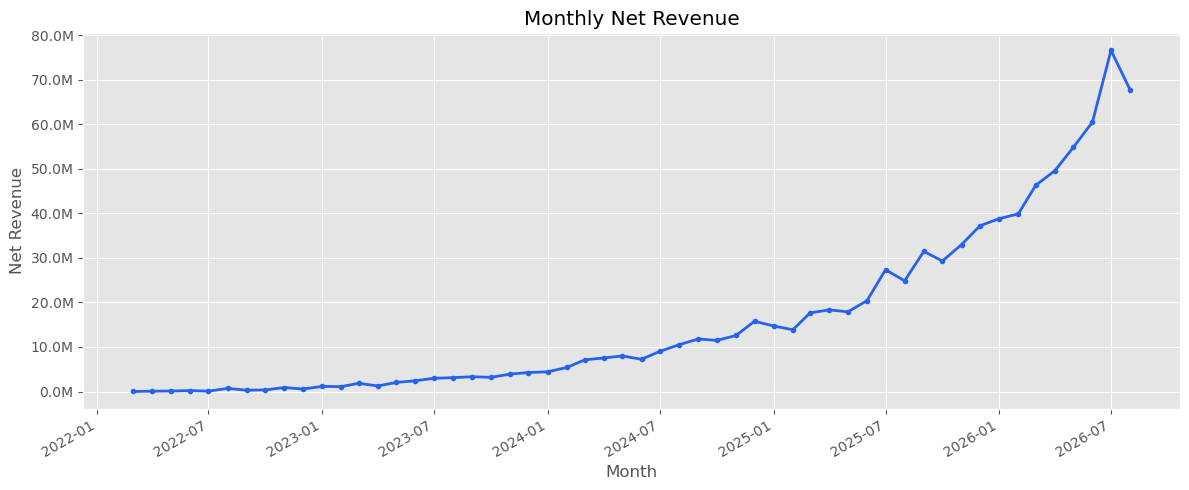

In [71]:
monthly_plot = monthly_revenue.copy()
monthly_plot["month"] = pd.to_datetime(monthly_plot["month"])
monthly_plot = monthly_plot.sort_values("month")

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly_plot["month"],
    monthly_plot["net_revenue"],
    color="#2563EB",
    linewidth=2,
    marker="o",
    markersize=3
)

ax.set_title("Monthly Net Revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Net Revenue")
ax.yaxis.set_major_formatter(millions)

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(charts_folder / "monthly_revenue.png", dpi=150)
plt.show()

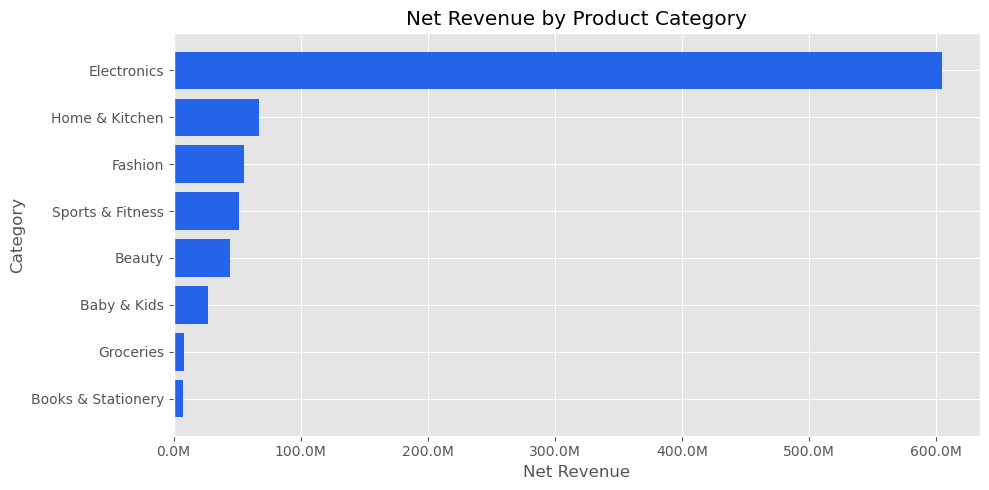

In [72]:
category_plot = category_revenue.sort_values("net_revenue")

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    category_plot["category"],
    category_plot["net_revenue"],
    color="#2563EB"
)

ax.set_title("Net Revenue by Product Category")
ax.set_xlabel("Net Revenue")
ax.set_ylabel("Category")
ax.xaxis.set_major_formatter(millions)

fig.tight_layout()
fig.savefig(charts_folder / "category_revenue.png", dpi=150)
plt.show()

In [73]:
city_query = """
SELECT
    c.city,
    ROUND(
        SUM(o.quantity * o.unit_price * (1 - o.discount) * (1 - o.returned)),
        2
    ) AS net_revenue,
    COUNT(o.order_id) AS order_count,
    COUNT(DISTINCT o.customer_id) AS purchasing_customers
FROM analysis_orders AS o
JOIN customers AS c
    ON o.customer_id = c.customer_id
GROUP BY c.city
ORDER BY net_revenue DESC, c.city;
"""

city_revenue = pd.read_sql_query(city_query, sql_connection)

display(city_revenue)

,city,net_revenue,order_count,purchasing_customers
0,Karachi,2.272322e+08,17171,1935
1,Lahore,1.577886e+08,11872,1323
2,Islamabad,8.365075e+07,6375,730
3,Rawalpindi,7.358560e+07,5556,591
4,Multan,5.840518e+07,4534,433
5,Faisalabad,5.627329e+07,4310,515
6,Peshawar,4.569314e+07,3151,365
7,Hyderabad,3.576117e+07,2699,289
8,Gujranwala,3.259689e+07,2468,289
9,Sialkot,2.673048e+07,1988,208


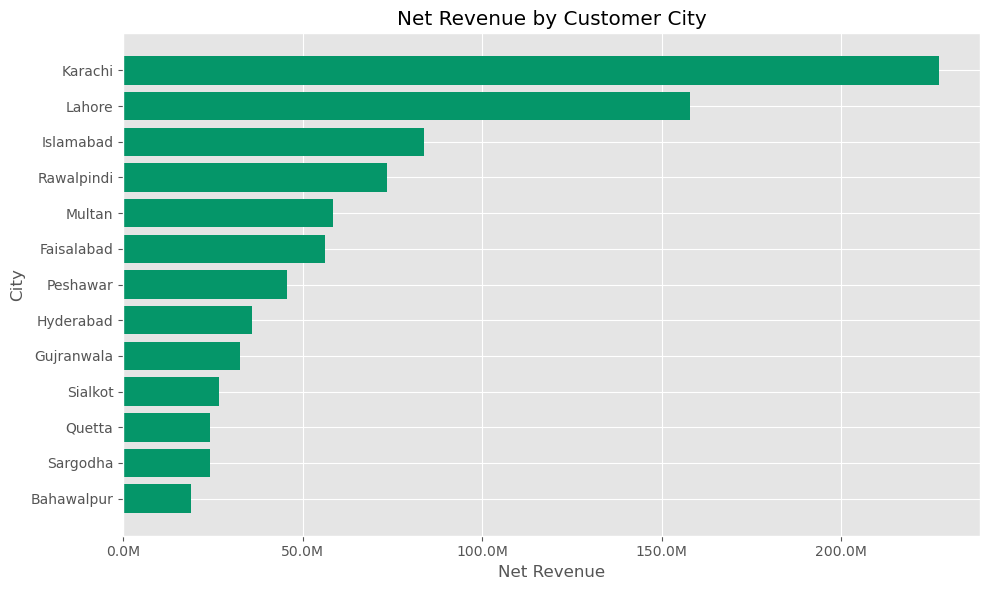

In [74]:
city_plot = city_revenue.sort_values("net_revenue")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    city_plot["city"],
    city_plot["net_revenue"],
    color="#059669"
)

ax.set_title("Net Revenue by Customer City")
ax.set_xlabel("Net Revenue")
ax.set_ylabel("City")
ax.xaxis.set_major_formatter(millions)

fig.tight_layout()
fig.savefig(charts_folder / "city_revenue.png", dpi=150)
plt.show()

In [75]:
return_query = """
SELECT
    p.category,
    COUNT(o.order_id) AS order_count,
    SUM(o.returned) AS returned_orders,
    100.0 * SUM(o.returned) / COUNT(o.order_id) AS return_rate_pct
FROM analysis_orders AS o
JOIN products AS p
    ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY return_rate_pct DESC, p.category;
"""

category_returns = pd.read_sql_query(return_query, sql_connection)

display(category_returns.round(2))

,category,order_count,returned_orders,return_rate_pct
0,Fashion,12236,1377,11.25
1,Electronics,11536,921,7.98
2,Home & Kitchen,7619,502,6.59
3,Beauty,11687,678,5.80
4,Sports & Fitness,7063,409,5.79
5,Baby & Kids,3746,213,5.69
6,Groceries,6081,139,2.29
7,Books & Stationery,4922,103,2.09


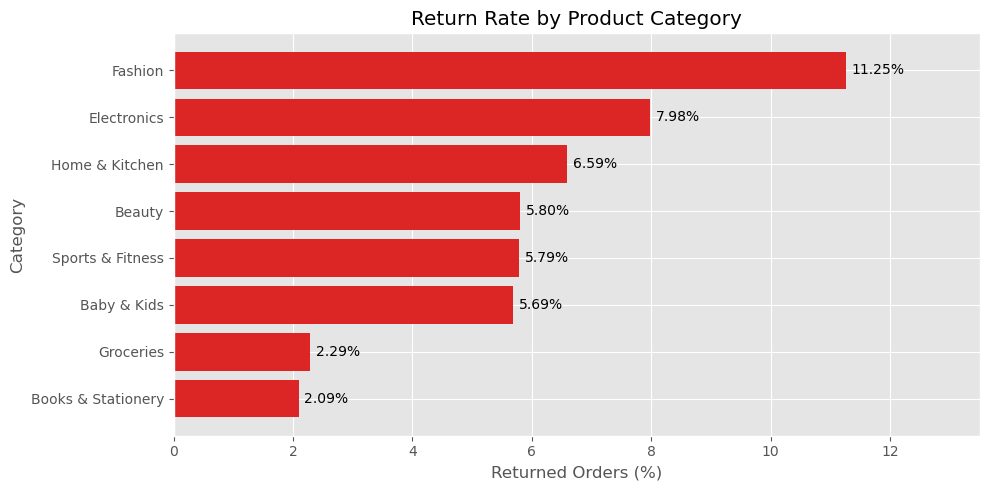

In [76]:
returns_plot = category_returns.sort_values("return_rate_pct")

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    returns_plot["category"],
    returns_plot["return_rate_pct"],
    color="#DC2626"
)

ax.bar_label(bars, fmt="%.2f%%", padding=4)
ax.set_xlim(0, max(1, returns_plot["return_rate_pct"].max() * 1.2))

ax.set_title("Return Rate by Product Category")
ax.set_xlabel("Returned Orders (%)")
ax.set_ylabel("Category")

fig.tight_layout()
fig.savefig(charts_folder / "category_return_rate.png", dpi=150)
plt.show()

In [77]:
total_net = category_revenue["net_revenue"].sum()

top_category = category_revenue.loc[
    category_revenue["net_revenue"].idxmax()
]

top_city = city_revenue.loc[
    city_revenue["net_revenue"].idxmax()
]

highest_return = category_returns.loc[
    category_returns["return_rate_pct"].idxmax()
]

insights = [
    (
        f"1. {top_category['category']} contributes "
        f"{100 * top_category['net_revenue'] / total_net:.1f}% of net revenue. "
        "Protect stock availability in this category and review profit margins "
        "before increasing purchasing or advertising budgets."
    ),
    (
        f"2. {top_city['city']} contributes "
        f"{100 * top_city['net_revenue'] / total_net:.1f}% of net revenue "
        f"from {int(top_city['purchasing_customers']):,} purchasing customers. "
        "Prioritize reliable delivery in this market. Compare revenue per customer "
        "before concluding that customers here spend more individually."
    ),
    (
        f"3. {highest_return['category']} has the highest return rate "
        f"at {highest_return['return_rate_pct']:.2f}% across "
        f"{int(highest_return['order_count']):,} orders. "
        "Investigate product descriptions, quality and return reasons "
        "to identify opportunities to reduce refunds and handling costs."
    )
]

for insight in insights:
    print(insight)
    print()

1. Electronics contributes 69.9% of net revenue. Protect stock availability in this category and review profit margins before increasing purchasing or advertising budgets.

2. Karachi contributes 26.3% of net revenue from 1,935 purchasing customers. Prioritize reliable delivery in this market. Compare revenue per customer before concluding that customers here spend more individually.

3. Fashion has the highest return rate at 11.25% across 12,236 orders. Investigate product descriptions, quality and return reasons to identify opportunities to reduce refunds and handling costs.



## Task D: Customer Churn Prediction

Features: purchase history through 31 May 2026.
Target: purchase activity from 1 June to 31 August 2026.

Churn = 1: no purchase during the target window.
Churn = 0: at least one purchase during the target window.

In [78]:


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

import joblib

In [79]:
churn_query = """
WITH history AS (
    SELECT
        customer_id,
        COUNT(order_id) AS total_orders,

        SUM(
            quantity * unit_price
            * (1 - discount) * (1 - returned)
        ) AS total_spending,

        AVG(
            quantity * unit_price
            * (1 - discount) * (1 - returned)
        ) AS average_order_value,

        CAST(
            julianday('2026-05-31') - julianday(MAX(order_date))
            AS INTEGER
        ) AS days_since_last_order,

        AVG(CAST(returned AS REAL)) AS return_rate,
        AVG(delivery_days) AS average_delivery_days

    FROM analysis_orders
    WHERE order_date < '2026-06-01'
    GROUP BY customer_id
),

target_activity AS (
    SELECT DISTINCT customer_id
    FROM analysis_orders
    WHERE order_date >= '2026-06-01'
      AND order_date < '2026-09-01'
)

SELECT
    h.customer_id,
    h.total_orders,
    h.total_spending,
    h.average_order_value,
    h.days_since_last_order,
    h.return_rate,
    h.average_delivery_days,
    c.age,
    c.membership_type,

    CASE
        WHEN t.customer_id IS NULL THEN 1
        ELSE 0
    END AS churn

FROM history AS h
JOIN customers AS c
    ON h.customer_id = c.customer_id
LEFT JOIN target_activity AS t
    ON h.customer_id = t.customer_id;
"""

churn_data = pd.read_sql_query(churn_query, sql_connection)

print("Dataset shape:", churn_data.shape)
display(churn_data.head())

Dataset shape: (6535, 10)


,customer_id,total_orders,total_spending,average_order_value,days_since_last_order,return_rate,average_delivery_days,age,membership_type,churn
0,2,3,6229.49896,2076.499653,3,0.0,4.666667,33.0,Silver,0
1,3,6,24102.46210,4017.077017,107,0.0,3.166667,25.0,Standard,1
2,4,5,14400.81290,2880.162580,13,0.0,3.000000,26.0,Standard,1
3,5,8,76312.80669,9539.100836,19,0.0,3.500000,27.0,Standard,0
4,6,3,50020.16297,16673.387657,440,0.0,3.000000,24.0,Standard,1


In [80]:
uncertain_customers = pd.read_sql_query("""
    SELECT DISTINCT customer_id
    FROM orders
    WHERE analysis_eligible = 0
      AND (
          order_date IS NULL
          OR (
              order_date >= '2026-06-01'
              AND order_date < '2026-09-01'
          )
      );
""", sql_connection)

# Known target-window purchase already establishes churn=0.
uncertain_labels = (
    churn_data["churn"].eq(1)
    & churn_data["customer_id"].isin(
        uncertain_customers["customer_id"]
    )
)

print("Customers excluded due to uncertain labels:",
      uncertain_labels.sum())

churn_data = churn_data.loc[~uncertain_labels].copy()

display(
    churn_data["churn"]
    .value_counts()
    .rename_axis("churn")
    .to_frame("customers")
)

print(f"Churn rate: {churn_data['churn'].mean():.2%}")

display(churn_data.isna().sum().to_frame("missing_count"))

Customers excluded due to uncertain labels: 3


,customers
churn,
0,3329
1,3203


Churn rate: 49.04%


,missing_count
customer_id,0
total_orders,0
total_spending,0
average_order_value,0
days_since_last_order,0
return_rate,0
average_delivery_days,0
age,0
membership_type,0
churn,0


In [81]:
numeric_features = [
    "total_orders",
    "total_spending",
    "average_order_value",
    "days_since_last_order",
    "return_rate",
    "average_delivery_days",
    "age"
]

categorical_features = ["membership_type"]

feature_columns = numeric_features + categorical_features

X = churn_data[feature_columns].copy()
y = churn_data["churn"].copy()

# Missing values ko sklearn-compatible representation dein.
X[numeric_features] = X[numeric_features].astype(float)

X["membership_type"] = (
    X["membership_type"]
    .astype(object)
    .where(X["membership_type"].notna(), np.nan)
)

# 20% final test set.
X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Remaining data se training + validation sets.
X_train, X_val, y_train, y_val = train_test_split(
    X_development,
    y_development,
    test_size=0.25,
    random_state=42,
    stratify=y_development
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)

Training: (3918, 8)
Validation: (1307, 8)
Test: (1307, 8)


Features use orders before June 2026; target-window purchases are
used only to create labels. Missing values will be imputed using
training data only.

The database does not provide historical membership, age, or
return/delivery status snapshots. I assume these values were
available at the cutoff. This limits point-in-time validity and
should be addressed with historical snapshots in production.

Customers with uncertain churn labels caused by invalid orders
were excluded. This may introduce selection bias.

In [82]:
def make_preprocessor():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ])

In [83]:
models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", make_preprocessor()),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", make_preprocessor()),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ])
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, "training complete")

Logistic Regression training complete
Random Forest training complete


In [84]:
def evaluate_model(name, model, X_eval, y_eval):
    predictions = model.predict(X_eval)

    churn_column = list(model.classes_).index(1)
    probabilities = model.predict_proba(X_eval)[:, churn_column]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, predictions),
        "Precision": precision_score(
            y_eval, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_eval, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_eval, predictions, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(y_eval, probabilities)
    }

In [85]:
validation_results = pd.DataFrame([
    evaluate_model(name, model, X_val, y_val)
    for name, model in models.items()
])

validation_results = validation_results.sort_values(
    ["F1", "ROC_AUC"],
    ascending=False
).reset_index(drop=True)

display(validation_results.round(4))

best_model_name = validation_results.iloc[0]["Model"]
best_model = models[best_model_name]

print("Selected model:", best_model_name)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.7146,0.6650,0.8424,0.7433,0.7787
1,Random Forest,0.6924,0.6613,0.7644,0.7091,0.7594


Selected model: Logistic Regression


In [86]:
from sklearn.dummy import DummyClassifier

# Simple baseline: always predict the most common training class.
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

test_results = pd.DataFrame([
    evaluate_model("Majority Baseline", baseline, X_test, y_test),
    *[
        evaluate_model(name, model, X_test, y_test)
        for name, model in models.items()
    ]
])

display(test_results.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Majority Baseline,0.5096,0.0000,0.0000,0.0000,0.5000
1,Logistic Regression,0.7169,0.6659,0.8487,0.7462,0.7889
2,Random Forest,0.7108,0.6775,0.7832,0.7265,0.7794


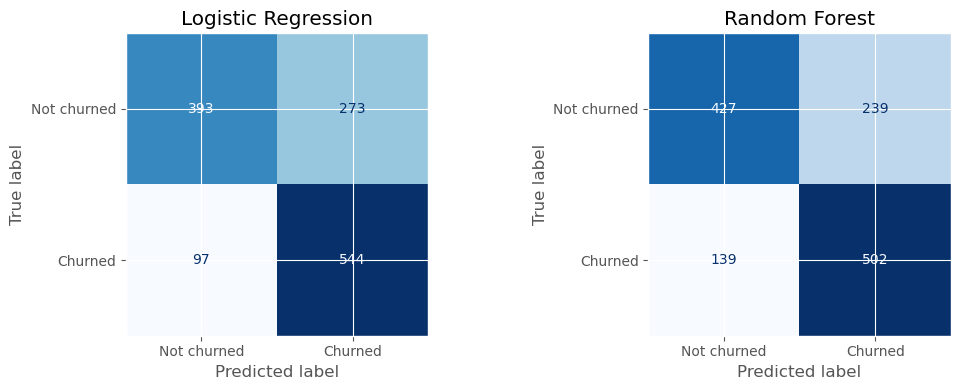

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, model) in zip(axes, models.items()):
    predictions = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=[0, 1],
        display_labels=["Not churned", "Churned"],
        cmap="Blues",
        colorbar=False,
        ax=ax
    )

    ax.set_title(name)

fig.tight_layout()
fig.savefig(
    charts_folder / "churn_confusion_matrices.svg",
    bbox_inches="tight"
)
plt.show()

In [88]:
import json
import sklearn

models_folder = Path("models")
models_folder.mkdir(exist_ok=True)

joblib.dump(
    best_model,
    models_folder / "churn_model.joblib"
)

validation_results.to_csv(
    models_folder / "churn_validation_metrics.csv",
    index=False
)

test_results.to_csv(
    models_folder / "churn_test_metrics.csv",
    index=False
)

metadata = {
    "selected_model": best_model_name,
    "selection_rule": "Highest validation F1; ROC-AUC breaks ties",
    "feature_columns": feature_columns,
    "feature_cutoff": "2026-05-31",
    "target_start": "2026-06-01",
    "target_end": "2026-08-31",
    "positive_class": 1,
    "decision_threshold": 0.5,
    "sklearn_version": sklearn.__version__
}

(models_folder / "churn_metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8"
)

print("Saved model:", models_folder / "churn_model.joblib")

Saved model: models\churn_model.joblib


In [89]:
loaded_model = joblib.load(
    models_folder / "churn_model.joblib"
)

sample = X_test.head(3)

assert np.allclose(
    best_model.predict_proba(sample),
    loaded_model.predict_proba(sample)
)

sample_results = sample.copy()
sample_results["actual_churn"] = y_test.loc[sample.index]

sample_results["predicted_churn"] = loaded_model.predict(sample)

churn_column = list(loaded_model.classes_).index(1)

sample_results["churn_probability"] = (
    loaded_model.predict_proba(sample)[:, churn_column]
)

display(sample_results)
print("Saved model verification passed.")

,total_orders,total_spending,average_order_value,days_since_last_order,return_rate,average_delivery_days,age,membership_type,actual_churn,predicted_churn,churn_probability
5355,1.0,833.48376,833.483760,7.0,0.000000,4.000000,26.0,Premium,0,1,0.549249
3129,4.0,17384.90547,4346.226367,136.0,0.000000,2.000000,38.0,Silver,1,1,0.578957
2264,17.0,85305.63847,5017.978734,94.0,0.117647,4.705882,21.0,Standard,0,0,0.161866


Saved model verification passed.


### Model Comparison

Both models outperform the majority baseline. Logistic Regression
achieved a test F1-score of 0.7462, recall of 0.8487 and ROC-AUC of
0.7889. Random Forest achieved slightly higher precision (0.6775),
but lower recall and F1.

The deployment model was selected using validation F1, with ROC-AUC
as a tie-breaker. The test set was used only for final evaluation.
High churn recall is useful for retention campaigns, although false
positives can increase campaign costs.

## Task E: Feed-Forward Neural Network

Architecture: input → 32 ReLU neurons → 16 ReLU neurons → binary output.
Loss: binary log loss (cross-entropy).
The same training, validation and test sets are used as in Task D.

In [90]:
from sklearn.neural_network import MLPClassifier

neural_network = Pipeline([
    ("preprocessor", make_preprocessor()),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        batch_size=64,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15,
        random_state=42
    ))
])

neural_network.fit(X_train, y_train)

print("Neural network training complete")
print(
    "Training iterations:",
    neural_network.named_steps["classifier"].n_iter_
)

Neural network training complete
Training iterations: 41


In [91]:
nn_validation_results = pd.DataFrame([
    evaluate_model(
        "Neural Network",
        neural_network,
        X_val,
        y_val
    )
])

nn_test_results = pd.DataFrame([
    evaluate_model(
        "Neural Network",
        neural_network,
        X_test,
        y_test
    )
])

print("Neural network validation metrics:")
display(nn_validation_results.round(4))

comparison_results = pd.concat(
    [
        test_results[
            test_results["Model"] != "Majority Baseline"
        ],
        nn_test_results
    ],
    ignore_index=True
)

print("Final test comparison:")
display(comparison_results.round(4))

Neural network validation metrics:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Neural Network,0.7024,0.676,0.7551,0.7133,0.7731


Final test comparison:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.7169,0.6659,0.8487,0.7462,0.7889
1,Random Forest,0.7108,0.6775,0.7832,0.7265,0.7794
2,Neural Network,0.7123,0.6879,0.7566,0.7207,0.7857


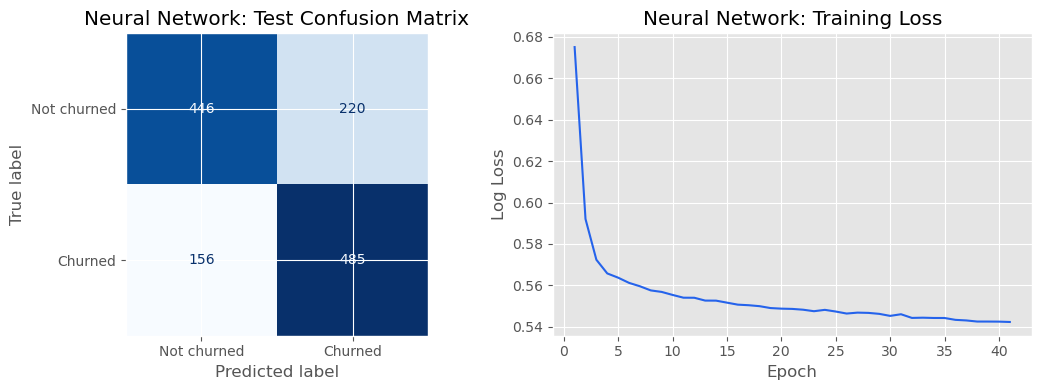

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    neural_network.predict(X_test),
    labels=[0, 1],
    display_labels=["Not churned", "Churned"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0]
)

axes[0].set_title("Neural Network: Test Confusion Matrix")

loss_curve = neural_network.named_steps["classifier"].loss_curve_

axes[1].plot(
    range(1, len(loss_curve) + 1),
    loss_curve,
    color="#2563EB"
)

axes[1].set_title("Neural Network: Training Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Log Loss")

fig.tight_layout()
fig.savefig(
    charts_folder / "neural_network_evaluation.svg",
    bbox_inches="tight"
)
plt.show()

In [93]:
joblib.dump(
    neural_network,
    models_folder / "churn_neural_network.joblib"
)

comparison_results.to_csv(
    models_folder / "churn_all_models_test_metrics.csv",
    index=False
)

print("Neural network and comparison saved.")

Neural network and comparison saved.


In [94]:

display(comparison_results.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.7169,0.6659,0.8487,0.7462,0.7889
1,Random Forest,0.7108,0.6775,0.7832,0.7265,0.7794
2,Neural Network,0.7123,0.6879,0.7566,0.7207,0.7857


## Task F: Review Sentiment Analysis

Rating 1–2: Negative
Rating 3: Neutral
Rating 4–5: Positive

Model: TF-IDF + Logistic Regression

In [97]:

sentiment_data = pd.read_sql_query("""
    SELECT
        r.review_id,
        r.rating,
        r.review_text
    FROM reviews AS r
    WHERE r.rating BETWEEN 1 AND 5
      AND r.review_text IS NOT NULL
      AND EXISTS (
          SELECT 1 FROM customers AS c
          WHERE c.customer_id = r.customer_id
      )
      AND EXISTS (
          SELECT 1 FROM products AS p
          WHERE p.product_id = r.product_id
      );
""", sql_connection)

# Spaces, tabs aur blank text handle karein.
sentiment_data["review_text"] = (
    sentiment_data["review_text"]
    .astype("string")
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

sentiment_data = sentiment_data.loc[
    sentiment_data["review_text"].ne("")
].copy()

sentiment_data["sentiment"] = np.select(
    [
        sentiment_data["rating"].isin([1, 2]),
        sentiment_data["rating"].eq(3)
    ],
    ["Negative", "Neutral"],
    default="Positive"
)

print("Usable reviews:", len(sentiment_data))
display(sentiment_data.head())
display(sentiment_data["sentiment"].value_counts())

Usable reviews: 25885


,review_id,rating,review_text,sentiment
0,1,4,"i would buy this again, item feels durable. re...",Positive
1,2,5,"very satisfied, seller description was accurat...",Positive
2,3,4,"very satisfied, quality feels premium. good va...",Positive
3,4,4,"product arrived in great condition, quality fe...",Positive
4,5,4,"good experience overall, packing was neat. wil...",Positive


sentiment
Positive    18421
Neutral      5458
Negative     2006
Name: count, dtype: int64

In [98]:
label_counts = (
    sentiment_data.groupby("review_text")["sentiment"].nunique()
)

conflicting_texts = label_counts[label_counts > 1].index

conflict_mask = sentiment_data["review_text"].isin(conflicting_texts)

print("Records with conflicting text labels:", conflict_mask.sum())

sentiment_data = sentiment_data.loc[~conflict_mask].copy()

before = len(sentiment_data)

sentiment_data = sentiment_data.drop_duplicates(
    subset="review_text"
).reset_index(drop=True)

print("Repeated text records removed:", before - len(sentiment_data))
print("Unique usable reviews:", len(sentiment_data))

display(sentiment_data["sentiment"].value_counts())

Records with conflicting text labels: 0
Repeated text records removed: 21401
Unique usable reviews: 4484


sentiment
Positive    2160
Neutral     1387
Negative     937
Name: count, dtype: int64

In [99]:
text_train, text_test, sentiment_train, sentiment_test = (
    train_test_split(
        sentiment_data["review_text"],
        sentiment_data["sentiment"],
        test_size=0.20,
        random_state=42,
        stratify=sentiment_data["sentiment"]
    )
)

assert set(text_train).isdisjoint(set(text_test))

print("Training reviews:", len(text_train))
print("Test reviews:", len(text_test))

Training reviews: 3587
Test reviews: 897


In [100]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

sentiment_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_features=15000,
        sublinear_tf=True
    )),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

sentiment_model.fit(text_train, sentiment_train)

print("Sentiment model training complete")

Sentiment model training complete


In [101]:
sentiment_predictions = sentiment_model.predict(text_test)

sentiment_metrics = pd.DataFrame([{
    "Accuracy": accuracy_score(
        sentiment_test, sentiment_predictions
    ),
    "Precision_macro": precision_score(
        sentiment_test,
        sentiment_predictions,
        average="macro",
        zero_division=0
    ),
    "Recall_macro": recall_score(
        sentiment_test,
        sentiment_predictions,
        average="macro",
        zero_division=0
    ),
    "F1_macro": f1_score(
        sentiment_test,
        sentiment_predictions,
        average="macro",
        zero_division=0
    )
}])

display(sentiment_metrics.round(4))

print(classification_report(
    sentiment_test,
    sentiment_predictions,
    labels=["Negative", "Neutral", "Positive"],
    zero_division=0
))

,Accuracy,Precision_macro,Recall_macro,F1_macro
0,1.0,1.0,1.0,1.0


              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       187
     Neutral       1.00      1.00      1.00       278
    Positive       1.00      1.00      1.00       432

    accuracy                           1.00       897
   macro avg       1.00      1.00      1.00       897
weighted avg       1.00      1.00      1.00       897



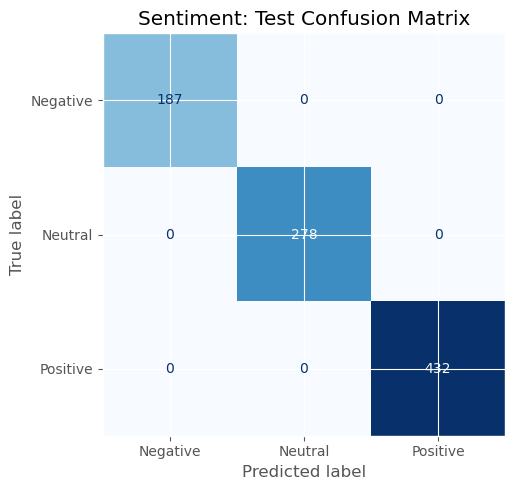

In [102]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    sentiment_test,
    sentiment_predictions,
    labels=["Negative", "Neutral", "Positive"],
    cmap="Blues",
    colorbar=False,
    ax=ax
)

ax.set_title("Sentiment: Test Confusion Matrix")

fig.tight_layout()
fig.savefig(
    charts_folder / "sentiment_confusion_matrix.svg",
    bbox_inches="tight"
)
plt.show()

In [103]:
joblib.dump(
    sentiment_model,
    models_folder / "sentiment_model.joblib"
)

sentiment_metrics.to_csv(
    models_folder / "sentiment_test_metrics.csv",
    index=False
)

loaded_sentiment = joblib.load(
    models_folder / "sentiment_model.joblib"
)

examples = [
    "Excellent quality and fast delivery",
    "The product is okay, nothing special",
    "Very disappointed, the item stopped working"
]

assert np.array_equal(
    sentiment_model.predict(examples),
    loaded_sentiment.predict(examples)
)

display(pd.DataFrame({
    "review": examples,
    "predicted_sentiment": loaded_sentiment.predict(examples)
}))

print("Saved sentiment model verification passed.")

,review,predicted_sentiment
0,Excellent quality and fast delivery,Positive
1,"The product is okay, nothing special",Neutral
2,"Very disappointed, the item stopped working",Negative


Saved sentiment model verification passed.


Ratings provide proxy sentiment labels rather than manually verified
text sentiment. A customer may give a low rating because of delivery
while writing positively about the product. Repeated template-like
reviews can also make this evaluation easier than real-world reviews;
removing exact duplicates does not remove all similar templates.

### Task G: Streamlit Application 

In [104]:
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [106]:


required_files = [
    Path("ecommerce_cleaned.db"),
    Path("models/churn_model.joblib"),
    Path("models/sentiment_model.joblib")
]

for file in required_files:
    print(file, "OK" if file.exists() else "MISSING")

assert all(file.exists() for file in required_files), (
    "Missing files: previous save cells run karein."
)

ecommerce_cleaned.db OK
models\churn_model.joblib OK
models\sentiment_model.joblib OK


In [122]:
%%writefile app.py
import sqlite3
import re
from pathlib import Path

import joblib
import pandas as pd
import streamlit as st

st.set_page_config(
    page_title="E-Commerce Customer Intelligence",
    page_icon="🛒",
    layout="wide"
)
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800&display=swap');

html, body, [class*="css"], .stApp {
    font-family: 'Inter', sans-serif;
}

.stApp {
    background: #f4f6fb;
    color: #172554;
}

.block-container {
    max-width: 1250px;
    padding-top: 2rem;
    padding-bottom: 3rem;
}

/* Sidebar */
[data-testid="stSidebar"] {
    background: #101b35;
}

[data-testid="stSidebar"] *,
[data-testid="stSidebar"] label {
    color: #e2e8f0 !important;
}

[data-testid="stSidebar"] [data-testid="stRadio"] > div {
    gap: 12px;
}

/* Headings */
h1 {
    font-weight: 800 !important;
    letter-spacing: -1px;
    color: #14213d;
}

h2, h3 {
    color: #14213d;
    font-weight: 700 !important;
}

/* Metric cards */
[data-testid="stMetric"] {
    background: #ffffff;
    border: 1px solid #e5eaf3;
    border-radius: 18px;
    padding: 22px;
    box-shadow: 0 6px 20px rgba(20, 33, 61, 0.04);
}

[data-testid="stMetricLabel"] {
    color: #64748b;
}

[data-testid="stMetricValue"] {
    color: #14213d;
    font-weight: 800;
}

/* Prediction forms */
[data-testid="stForm"] {
    background: #ffffff;
    border: 1px solid #e5eaf3;
    border-radius: 20px;
    padding: 24px;
    box-shadow: 0 8px 24px rgba(20, 33, 61, 0.04);
}

/* Input fields */
[data-testid="stNumberInput"] input,
[data-testid="stTextInput"] input,
[data-testid="stTextArea"] textarea {
    color: #14213d;
    background: #f8fafc;
}

[data-testid="stTextArea"] textarea {
    border-radius: 12px;
}

/* Buttons */
.stButton > button,
.stFormSubmitButton > button {
    background: #2563eb;
    color: #ffffff;
    border: 0;
    border-radius: 12px;
    padding: 12px 24px;
    font-weight: 600;
    transition: background 0.2s ease, transform 0.2s ease;
}

.stButton > button:hover,
.stFormSubmitButton > button:hover {
    background: #1d4ed8;
    color: #ffffff;
    transform: translateY(-1px);
}

.stButton > button:focus-visible,
.stFormSubmitButton > button:focus-visible {
    outline: 3px solid #93c5fd;
    outline-offset: 3px;
}

/* Tables */
[data-testid="stDataFrame"] {
    border-radius: 14px;
    overflow: hidden;
}

/* Custom header */
.commerce-hero {
    background: linear-gradient(120deg, #14213d, #1e40af);
    padding: 32px;
    border-radius: 22px;
    margin-bottom: 28px;
    box-shadow: 0 12px 30px rgba(30, 64, 175, 0.15);
}

.commerce-hero .eyebrow {
    color: #bfdbfe;
    font-size: 12px;
    font-weight: 700;
    letter-spacing: 2px;
    text-transform: uppercase;
}

.commerce-hero h1 {
    color: #ffffff !important;
    font-size: clamp(26px, 4vw, 38px);
    line-height: 1.2;
    margin: 12px 0;
}

.commerce-hero p {
    color: #dbeafe;
    font-size: 15px;
    margin: 0;
}

.sidebar-brand {
    padding: 12px 0 24px;
}

.sidebar-brand .brand-name {
    font-size: 25px;
    font-weight: 800;
    color: white;
}

.sidebar-brand .brand-description {
    font-size: 12px;
    color: #94a3b8 !important;
    margin-top: 6px;
}

@media (max-width: 640px) {
    .commerce-hero {
        padding: 22px;
    }

    [data-testid="stForm"] {
        padding: 16px;
    }
}
</style>
""", unsafe_allow_html=True)



st.markdown("""
<div class="commerce-hero">
    <div class="eyebrow">E-Commerce Analytics</div>
    <h1>Understand your customers.<br>Grow your business.</h1>
    <p>
        Explore sales performance, identify churn risk,
        and understand customer feedback.
    </p>
</div>
""", unsafe_allow_html=True)
st.sidebar.markdown("""
<div class="sidebar-brand">
    <div class="brand-name">🛒 CommerceIQ</div>
    <div class="brand-description">Customer Intelligence Dashboard</div>
</div>
""", unsafe_allow_html=True)
BASE_DIR = Path(__file__).resolve().parent
DB_PATH = BASE_DIR / "ecommerce_cleaned.db"
MODEL_DIR = BASE_DIR / "models"

required = [
    DB_PATH,
    MODEL_DIR / "churn_model.joblib",
    MODEL_DIR / "sentiment_model.joblib"
]

missing = [str(path.name) for path in required if not path.exists()]
if missing:
    st.error("Missing required files: " + ", ".join(missing))
    st.stop()


@st.cache_resource
def load_model(filename):
    return joblib.load(MODEL_DIR / filename)


@st.cache_data
def query_database(query):
    with sqlite3.connect(
        DB_PATH.as_uri() + "?mode=ro",
        uri=True
    ) as connection:
        return pd.read_sql_query(query, connection)




page = st.sidebar.radio(
    "Navigation",
    ["Dashboard", "Churn Prediction", "Sentiment Analysis"]
)

if page == "Dashboard":
    st.header("Business Dashboard")

    # Dashboard outputs are calculated directly using SQLite SQL.
    revenue = query_database("""
        SELECT COALESCE(
            SUM(quantity * unit_price
                * (1 - discount) * (1 - returned)),
            0
        ) AS revenue
        FROM analysis_orders
    """).iloc[0]["revenue"]

    order_count = query_database("""
        SELECT COUNT(*) AS orders
        FROM analysis_orders
    """).iloc[0]["orders"]

    customer_count = query_database("""
        SELECT COUNT(*) AS customers
        FROM customers
    """).iloc[0]["customers"]

    col1, col2, col3 = st.columns(3)
    col1.metric("Total Net Revenue", f"{revenue:,.2f}")
    col2.metric("Valid Orders", f"{int(order_count):,}")
    col3.metric("Registered Customers", f"{int(customer_count):,}")

    st.caption(
        "Discounts are fractional rates. Returned orders are assumed "
        "fully refunded; revenue is adjusted in the original order month."
    )

    monthly = query_database("""
        SELECT
            strftime('%Y-%m', order_date) AS month,
            SUM(quantity * unit_price
                * (1 - discount) * (1 - returned)) AS net_revenue
        FROM analysis_orders
        GROUP BY strftime('%Y-%m', order_date)
        ORDER BY month
    """)

    categories = query_database("""
        SELECT
            p.category,
            SUM(o.quantity * o.unit_price
                * (1 - o.discount) * (1 - o.returned)) AS net_revenue
        FROM analysis_orders AS o
        JOIN products AS p ON o.product_id = p.product_id
        GROUP BY p.category
        ORDER BY net_revenue DESC
    """)

    st.subheader("Monthly Net Revenue")
    monthly["month"] = pd.to_datetime(monthly["month"])
    st.line_chart(monthly.set_index("month")["net_revenue"])

    st.subheader("Category Net Revenue")
    st.bar_chart(categories.set_index("category")["net_revenue"])
    st.dataframe(categories, hide_index=True)

elif page == "Churn Prediction":
    st.header("Customer Churn Prediction")
    st.caption(
        "Enter purchase-history features as of 31 May 2026. "
        "The model predicts no purchase during June–August 2026."
    )

    model = load_model("churn_model.joblib")

    # Membership options come from the fitted training encoder.
    memberships = list(
        model.named_steps["preprocessor"]
        .named_transformers_["categorical"]
        .named_steps["encoder"]
        .categories_[0]
    )

    with st.form("churn_form"):
        col1, col2 = st.columns(2)

        with col1:
            total_orders = st.number_input(
                "Total Orders", min_value=1, value=10, step=1
            )
            total_spending = st.number_input(
                "Total Net Spending", min_value=0.0, value=50000.0
            )
            days_since_last_order = st.number_input(
                "Days Since Last Order", min_value=0, value=30, step=1
            )
            return_pct = st.number_input(
                "Return Rate (%)",
                min_value=0.0,
                max_value=100.0,
                value=10.0
            )

        with col2:
            average_order_value = total_spending / total_orders
            st.metric("Average Net Order Value", f"{average_order_value:,.2f}")

            unknown_delivery = st.checkbox("Average Delivery Days Unknown")
            delivery = st.number_input(
                "Average Delivery Days",
                min_value=0.0,
                value=4.0
            )

            unknown_age = st.checkbox("Age Unknown")
            age = st.number_input(
                "Age", min_value=18, max_value=100, value=30, step=1
            )
            membership = st.selectbox("Membership Type", memberships)

        submitted = st.form_submit_button("Predict Churn")

    if submitted:
        customer = pd.DataFrame([{
            "total_orders": total_orders,
            "total_spending": total_spending,
            "average_order_value": average_order_value,
            "days_since_last_order": days_since_last_order,
            "return_rate": return_pct / 100,
            "average_delivery_days": (
                float("nan") if unknown_delivery else delivery
            ),
            "age": float("nan") if unknown_age else age,
            "membership_type": membership
        }])

        churn_column = list(model.classes_).index(1)
        probability = float(
            model.predict_proba(customer)[0, churn_column]
        )
        prediction = int(model.predict(customer)[0])

        st.metric("Estimated Churn Probability", f"{probability:.1%}")

        if prediction == 1:
            st.warning("Prediction: Churn")
        else:
            st.success("Prediction: Not Churn")

        st.caption(
            "Model probabilities are estimates and have not been calibrated."
        )

else:
    st.header("Review Sentiment Analysis")
    model = load_model("sentiment_model.joblib")

    with st.form("sentiment_form"):
        review = st.text_area(
            "Customer Review",
            placeholder="Enter a product review..."
        )
        submitted = st.form_submit_button("Analyze Sentiment")

    if submitted:
        cleaned_review = re.sub(r"\s+", " ", review.lower()).strip()

        if not cleaned_review:
            st.warning("Please enter a review.")
        else:
            prediction = model.predict([cleaned_review])[0]
            st.success(f"Predicted Sentiment: {prediction}")

            probabilities = model.predict_proba([cleaned_review])[0]
            st.dataframe(pd.DataFrame({
                "Sentiment": model.classes_,
                "Model Probability": probabilities
            }), hide_index=True)

            st.caption(
                "Training labels were derived from ratings. "
                "Text sentiment can differ from the customer's rating."
            )

Overwriting app.py


In [ ]:
from pathlib import Path

app_path = Path("app.py")
code = app_path.read_text(encoding="utf-8")

lines = code.splitlines(keepends=True)

cleaned_lines = [
    line for line in lines
    if not (
        "st.title(" in line
        and "E-Commerce Customer Intelligence" in line
    )
]

app_path.write_text(
    "".join(cleaned_lines),
    encoding="utf-8"
)

print("Duplicate title lines removed.")

In [108]:
from importlib.metadata import version

packages = [
    "streamlit",
    "pandas",
    "numpy",
    "scikit-learn",
    "scipy",
    "joblib",
    "matplotlib"
]

requirements = "\n".join(
    f"{package}=={version(package)}"
    for package in packages
)

Path("requirements.txt").write_text(
    requirements + "\n",
    encoding="utf-8"
)

print(requirements)

streamlit==1.51.0
pandas==2.3.3
numpy==2.3.5
scikit-learn==1.7.2
scipy==1.16.3
joblib==1.5.2
matplotlib==3.10.6


In [109]:
import ast

ast.parse(Path("app.py").read_text(encoding="utf-8"))
print("App syntax check passed.")

App syntax check passed.


In [110]:
import sys
print(sys.executable)

C:\Users\anas\anaconda3\python.exe


In [111]:
print(f'& "{sys.executable}" -m streamlit run app.py')

& "C:\Users\anas\anaconda3\python.exe" -m streamlit run app.py


###  Task H: GitHub and Streamlit Community cloud

In [113]:
from pathlib import Path
import sys

readme = f"""
# E-Commerce Customer Intelligence

An end-to-end project covering SQLite data cleaning, SQL analysis,
EDA, churn modeling, a neural network, sentiment analysis and Streamlit.

## Application
- Dashboard with SQL-based metrics and charts.
- Customer churn prediction using a saved model.
- Review sentiment analysis using a saved NLP model.

## Business Insights
1. Electronics contributes approximately 69.9% of net revenue.
   Protect stock availability and review profit margins.
2. Karachi contributes approximately 26.3% of net revenue from
   1,935 purchasing customers. Prioritize delivery reliability.
3. Fashion has an approximately 11.25% return rate across 12,236 orders.
   Investigate return reasons, product descriptions and quality.

## Churn Methodology
Features use orders through 31 May 2026.
The target window is 1 June to 31 August 2026.
Churn = 1 means no purchase during the target window.

Preprocessing is fitted on training data only.
ML selection uses validation F1, with ROC-AUC as a tie-breaker.
All churn models use the same test customers.

## Models
- Logistic Regression
- Random Forest
- Feed-forward neural network: 32 and 16 hidden neurons
- Sentiment: TF-IDF plus Logistic Regression

Evaluation results are available in the models folder.

## Assumptions and Limitations
- Discounts are fractional rates.
- Returned orders are assumed fully refunded.
- Revenue uses historical order prices.
- Invalid orders are preserved with quality flags.
- Historical membership and return/delivery snapshots are unavailable.
- Excluding uncertain churn labels may introduce selection bias.
- Rating-derived sentiment labels may differ from text sentiment.
- Similar review templates may inflate NLP evaluation.
- Churn probabilities are not calibrated.

## Run Locally
Training Python version: {sys.version.split()[0]}

    python -m pip install -r requirements.txt
    python -m streamlit run app.py

## Reproduce Analysis
Open the project notebook and run its cells in order.
Cleaning requires ecommerce_hackathon.db.
The app uses ecommerce_cleaned.db and saved models.

## Submission Links
GitHub repository: To be added
Live Streamlit app: To be added
"""

Path("README.md").write_text(
    readme.strip() + "\n",
    encoding="utf-8"
)

print("README.md saved successfully")

README.md saved successfully


In [114]:


Path(".gitignore").write_text(
    """__pycache__/
*.pyc
.ipynb_checkpoints/
.venv/
venv/
.env
.streamlit/secrets.toml
anaconda_projects/
""",
    encoding="utf-8"
)

print(".gitignore saved")

.gitignore saved


In [115]:
required = [
    "app.py",
    "README.md",
    "requirements.txt",
    "business_queries.sql",
    "ecommerce_hackathon.db",
    "ecommerce_cleaned.db",
    "models/churn_model.joblib",
    "models/churn_neural_network.joblib",
    "models/sentiment_model.joblib",
    "models/churn_all_models_test_metrics.csv",
    "models/sentiment_test_metrics.csv"
]

for filename in required:
    file = Path(filename)
    if file.exists():
        size_mb = file.stat().st_size / (1024 ** 2)
        print(f"OK       {filename} ({size_mb:.2f} MB)")
    else:
        print(f"MISSING  {filename}")

print("\nNotebooks:")
for notebook in Path(".").glob("*.ipynb"):
    print(notebook.name)

OK       app.py (0.01 MB)
OK       README.md (0.00 MB)
OK       requirements.txt (0.00 MB)
OK       business_queries.sql (0.00 MB)
OK       ecommerce_hackathon.db (10.53 MB)
OK       ecommerce_cleaned.db (7.63 MB)
OK       models/churn_model.joblib (0.00 MB)
OK       models/churn_neural_network.joblib (0.03 MB)
OK       models/sentiment_model.joblib (0.06 MB)
OK       models/churn_all_models_test_metrics.csv (0.00 MB)
OK       models/sentiment_test_metrics.csv (0.00 MB)

Notebooks:
01_Database_Inspection_Cleaning.ipynb.ipynb


In [124]:
from pathlib import Path

project = Path.cwd()

required_files = [
    "app.py",
    "requirements.txt",
    "README.md",
    "business_queries.sql",
    "ecommerce_hackathon.db",
    "ecommerce_cleaned.db",
    "models/churn_model.joblib",
    "models/churn_neural_network.joblib",
    "models/sentiment_model.joblib",
]

for filename in required_files:
    path = project / filename
    status = "OK" if path.is_file() else "MISSING"
    print(f"{status}: {filename}")

print("\nNotebooks:")
for notebook in project.glob("*.ipynb"):
    print(notebook.name)

OK: app.py
OK: requirements.txt
OK: README.md
OK: business_queries.sql
OK: ecommerce_hackathon.db
OK: ecommerce_cleaned.db
OK: models/churn_model.joblib
OK: models/churn_neural_network.joblib
OK: models/sentiment_model.joblib

Notebooks:
Ecommerce_Hackathon.ipynb
